# Singular Value Decomposition

https://colab.research.google.com/drive/1a44L_QygOLM-ImqnY0EigkHW4kJj933H?usp=sharing

===== DATASET =====
stallone : 23 gambar
taylor : 20 gambar
arnold : 25 gambar

===== INFORMASI DATASET =====
Jumlah gambar: 68
Jumlah pixel: 10000
Ukuran matriks A: (68, 10000)

===== MEAN FACE =====
Ukuran Mean Face: (10000,)

===== SVD =====
Ukuran U: (68, 68)
Ukuran S: (68,)
Ukuran VT: (68, 10000)

5x5 Sigma Pertama
[[27510.68018773     0.             0.             0.
      0.        ]
 [    0.         18310.9218014      0.             0.
      0.        ]
 [    0.             0.         13928.59135135     0.
      0.        ]
 [    0.             0.             0.         13049.95466049
      0.        ]
 [    0.             0.             0.             0.
  10810.19474813]]

===== EIGENFACES =====
Jumlah komponen: 10
Ukuran Eigenfaces: (10, 10000)

Ukuran fitur training: (68, 10)
Ukuran fitur test: (10,)

===== HASIL FACE RECOGNITION =====
Identitas: stallone
File terdekat: dataset/stallone/stallone13.jpg
Jarak: 2847.74
Kemiripan: 73.35 %

Error Rekonstruksi: 1.3138856891416667

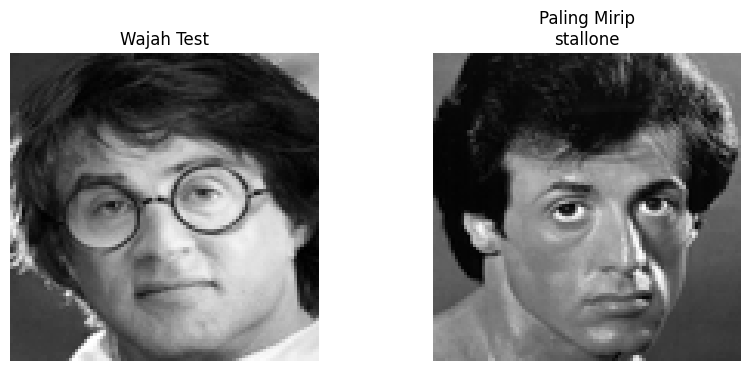

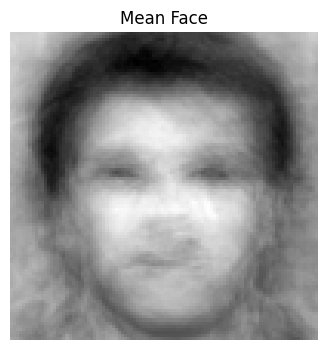

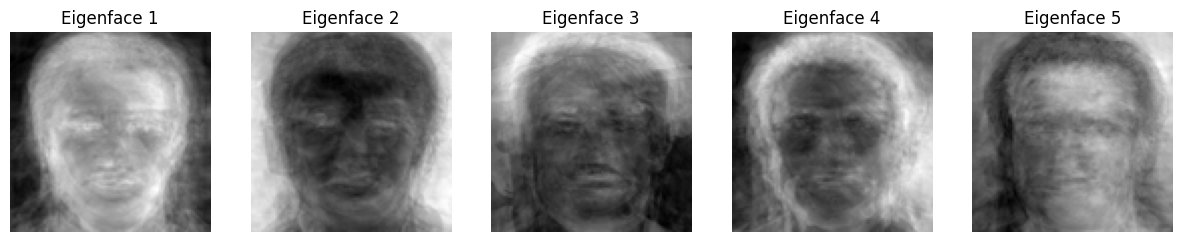

In [ ]:
# ==================================================
# EIGENFACES FACE RECOGNITION MENGGUNAKAN SVD
# ==================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from ipywidgets import interact
import ipywidgets as widgets

# ==================================================
# KONFIGURASI
# ==================================================

folder_dataset = "dataset"
file_test = "images/test.jpg"

ukuran_gambar = (100,100)
jumlah_komponen = 10

# ==================================================
# CEK FILE
# ==================================================

if not os.path.exists(folder_dataset):
    raise FileNotFoundError(
        f"Folder '{folder_dataset}' tidak ditemukan"
    )

if not os.path.exists(file_test):
    raise FileNotFoundError(
        f"File '{file_test}' tidak ditemukan"
    )

# ==================================================
# TAMPILKAN STRUKTUR DATASET
# ==================================================

print("===== DATASET =====")

for orang in os.listdir(folder_dataset):

    folder = os.path.join(
        folder_dataset,
        orang
    )

    if os.path.isdir(folder):

        jumlah = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(
                (".jpg",".jpeg",".png")
            )
        ])

        print(
            f"{orang} : {jumlah} gambar"
        )

# ==================================================
# FUNGSI MEMBACA GAMBAR
# ==================================================

def baca_gambar(path):

    gambar = Image.open(path)

    gambar = gambar.convert("L")

    gambar = gambar.resize(
        ukuran_gambar
    )

    matriks = np.array(
        gambar,
        dtype=np.float64
    )

    return matriks.flatten()

# ==================================================
# MEMBACA DATASET
# ==================================================

data_wajah = []
label_wajah = []
path_wajah = []

for nama_orang in os.listdir(folder_dataset):

    folder_orang = os.path.join(
        folder_dataset,
        nama_orang
    )

    if os.path.isdir(folder_orang):

        for file in os.listdir(folder_orang):

            if file.lower().endswith(
                (".jpg",".jpeg",".png")
            ):

                path = os.path.join(
                    folder_orang,
                    file
                )

                data_wajah.append(
                    baca_gambar(path)
                )

                label_wajah.append(
                    nama_orang
                )

                path_wajah.append(
                    path
                )

data_wajah = np.array(
    data_wajah
)

if len(data_wajah) == 0:
    raise ValueError(
        "Dataset kosong"
    )

# ==================================================
# INFORMASI DATASET
# ==================================================

print("\n===== INFORMASI DATASET =====")

print(
    "Jumlah gambar:",
    data_wajah.shape[0]
)

print(
    "Jumlah pixel:",
    data_wajah.shape[1]
)

print(
    "Ukuran matriks A:",
    data_wajah.shape
)

# ==================================================
# MEAN FACE
# ==================================================

rata_rata_wajah = np.mean(
    data_wajah,
    axis=0
)

data_tengah = (
    data_wajah -
    rata_rata_wajah
)

print("\n===== MEAN FACE =====")

print(
    "Ukuran Mean Face:",
    rata_rata_wajah.shape
)

# ==================================================
# SVD
# ==================================================

U,S,VT = np.linalg.svd(
    data_tengah,
    full_matrices=False
)

Sigma = np.diag(S)

print("\n===== SVD =====")

print(
    "Ukuran U:",
    U.shape
)

print(
    "Ukuran S:",
    S.shape
)

print(
    "Ukuran VT:",
    VT.shape
)

print("\n5x5 Sigma Pertama")

print(
    Sigma[:5,:5]
)

# ==================================================
# EIGENFACES
# ==================================================

k = min(
    jumlah_komponen,
    VT.shape[0]
)

eigenfaces = VT[:k]

print("\n===== EIGENFACES =====")

print(
    "Jumlah komponen:",
    k
)

print(
    "Ukuran Eigenfaces:",
    eigenfaces.shape
)

# ==================================================
# PROYEKSI TRAINING
# ==================================================

fitur_training = np.dot(
    data_tengah,
    eigenfaces.T
)

print(
    "\nUkuran fitur training:",
    fitur_training.shape
)

# ==================================================
# WAJAH TEST
# ==================================================

wajah_test = baca_gambar(
    file_test
)

wajah_test_tengah = (
    wajah_test -
    rata_rata_wajah
)

fitur_test = np.dot(
    wajah_test_tengah,
    eigenfaces.T
)

print(
    "Ukuran fitur test:",
    fitur_test.shape
)

# ==================================================
# EUCLIDEAN DISTANCE
# ==================================================

jarak = np.linalg.norm(
    fitur_training -
    fitur_test,
    axis=1
)

index_terdekat = np.argmin(
    jarak
)

hasil_nama = label_wajah[
    index_terdekat
]

hasil_path = path_wajah[
    index_terdekat
]

jarak_min = jarak[
    index_terdekat
]

kemiripan = max(
    0,
    100 -
    (jarak_min /
     np.max(jarak))*100
)

# ==================================================
# HASIL IDENTIFIKASI
# ==================================================

print("\n===== HASIL FACE RECOGNITION =====")

print(
    "Identitas:",
    hasil_nama
)

print(
    "File terdekat:",
    hasil_path
)

print(
    "Jarak:",
    round(
        jarak_min,
        2
    )
)

print(
    "Kemiripan:",
    round(
        kemiripan,
        2
    ),
    "%"
)

# ==================================================
# VERIFIKASI SVD
# ==================================================

A_rekonstruksi = (
    U @
    np.diag(S) @
    VT
)

error = np.linalg.norm(
    data_tengah -
    A_rekonstruksi
)

print(
    "\nError Rekonstruksi:",
    error
)

# ==================================================
# TAMPILKAN TEST DAN HASIL
# ==================================================

gambar_test = Image.open(
    file_test
).convert("L")

gambar_test = gambar_test.resize(
    ukuran_gambar
)

gambar_hasil = Image.open(
    hasil_path
).convert("L")

gambar_hasil = gambar_hasil.resize(
    ukuran_gambar
)

plt.figure(
    figsize=(10,4)
)

plt.subplot(1,2,1)

plt.imshow(
    gambar_test,
    cmap="gray"
)

plt.title(
    "Wajah Test"
)

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(
    gambar_hasil,
    cmap="gray"
)

plt.title(
    f"Paling Mirip\n{hasil_nama}"
)

plt.axis("off")

plt.show()

# ==================================================
# MEAN FACE
# ==================================================

plt.figure(
    figsize=(4,4)
)

plt.imshow(
    rata_rata_wajah.reshape(
        ukuran_gambar
    ),
    cmap="gray"
)

plt.title(
    "Mean Face"
)

plt.axis("off")

plt.show()

# ==================================================
# EIGENFACES
# ==================================================

jumlah_tampil = min(
    5,
    k
)

plt.figure(
    figsize=(15,3)
)

for i in range(
    jumlah_tampil
):

    plt.subplot(
        1,
        jumlah_tampil,
        i+1
    )

    plt.imshow(
        eigenfaces[i].reshape(
            ukuran_gambar
        ),
        cmap="gray"
    )

    plt.title(
        f"Eigenface {i+1}"
    )

    plt.axis("off")

plt.show()

# ==================================================
# SLIDER EIGENFACE
# ==================================================

@interact(index=(0,k-1))

def tampilkan_eigenface(index):

    plt.figure(figsize=(4,4))

    plt.imshow(
        eigenfaces[index].reshape(
            ukuran_gambar
        ),
        cmap="gray"
    )

    plt.title(
        f"Eigenface {index+1}"
    )

    plt.axis("off")

    plt.show()

# ==================================================
# EIGENVALUE
# ==================================================

AA_T = np.dot(
    data_tengah,
    data_tengah.T
)

eigenvalue, eigenvector = np.linalg.eig(
    AA_T
)

idx = np.argsort(
    eigenvalue
)[::-1]

eigenvalue = eigenvalue[idx]

eigenvector = eigenvector[:,idx]

plt.figure(
    figsize=(8,4)
)

plt.plot(
    range(
        1,
        len(eigenvalue)+1
    ),
    eigenvalue,
    marker='o'
)

plt.title(
    "Grafik Eigenvalue"
)

plt.xlabel(
    "Komponen"
)

plt.ylabel(
    "Eigenvalue"
)

plt.grid()

plt.show()

print("\n5 Eigenvalue Terbesar")

for i in range(
    min(
        5,
        len(eigenvalue)
    )
):
    print(
        f"λ{i+1} = {eigenvalue[i]:.2f}"
    )

# ==================================================
# REKONSTRUKSI WAJAH
# ==================================================

@interact(
    k_rek=widgets.IntSlider(
        min=1,
        max=min(
            50,
            VT.shape[0]
        ),
        step=1,
        value=10,
        description='k'
    )
)

def rekonstruksi_wajah(k_rek):

    eigen_k = VT[:k_rek]

    fitur = np.dot(
        wajah_test_tengah,
        eigen_k.T
    )

    hasil = (
        rata_rata_wajah +
        np.dot(
            fitur,
            eigen_k
        )
    )

    plt.figure(
        figsize=(5,5)
    )

    plt.imshow(
        hasil.reshape(
            ukuran_gambar
        ),
        cmap='gray'
    )

    plt.title(
        f"Rekonstruksi k={k_rek}"
    )

    plt.axis('off')

    plt.show()

# ==================================================
# PENJELASAN
# ==================================================

print("\n===== ALUR PROGRAM =====")

print("1. Dataset wajah dibaca.")
print("2. Semua gambar diubah menjadi grayscale.")
print("3. Gambar diresize menjadi 100x100.")
print("4. Dibentuk matriks A.")
print("5. Dihitung Mean Face.")
print("6. Data dicentering.")
print("7. Dilakukan SVD (A = UΣVᵀ).")
print("8. Diambil komponen utama.")
print("9. Dibentuk Eigenfaces.")
print("10. Data training diproyeksikan.")
print("11. Wajah test diproyeksikan.")
print("12. Dihitung Euclidean Distance.")
print("13. Dicari wajah paling mirip.")
print("14. Ditampilkan hasil pengenalan.")
